# Riff 1 Creating a Heirarchical Cluster Diagram

With this Diagram we hope to find Either clustering around the Author or Clustering around each Series


## Import Packages

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import norm
from scipy.spatial.distance import pdist
import scipy.cluster.hierarchy as sch

sns.set_theme(style='white')


## Import Tables

In [63]:
OHCO = ['title', 'chapter_id']
colors = 'YlGnBu'

In [29]:
directory_path = 'C:/Users/mason/Box/Text As Data Final/Output'
TFIDF_BAG = pd.read_csv(f"{directory_path}/BrandonSanderson_TFIDF.csv").set_index(OHCO)
TFIDF_BAG.head()

0   04   05    1   10  10010  10584  109thand  \
title             chapter_id                                                    
A Memory of Light 0           0.0  0.0  0.0  0.0  0.0    0.0    0.0       0.0   
                  1           0.0  0.0  0.0  0.0  0.0    0.0    0.0       0.0   
                  2           0.0  0.0  0.0  0.0  0.0    0.0    0.0       0.0   
                  3           0.0  0.0  0.0  0.0  0.0    0.0    0.0       0.0   
                  4           0.0  0.0  0.0  0.0  0.0    0.0    0.0       0.0   

                               11  1167  ...  ﬂowers  ﬂuidity  ﬂush  ﬂushed  \
title             chapter_id             ...                                  
A Memory of Light 0           0.0   0.0  ...     0.0      0.0   0.0     0.0   
                  1           0.0   0.0  ...     0.0      0.0   0.0     0.0   
                  2           0.0   0.0  ...     0.0      0.0   0.0     0.0   
                  3           0.0   0.0  ...     0.0      0.0   0.0     0.0   
                  4           0.0   0.0  ...     0.0      0.0   0.0     0.0   

                              ﬂushedi  ﬂushing  ﬂushingi  ﬂushingit  \
title             chapter_id                                          
A Memory of Light 0               0.0      0.0       0.0        0.0   
                  1               0.0      0.0       0.0        0.0   
                  2               0.0      0.0       0.0        0.0   
                  3               0.0      0.0       0.0        0.0   
                  4               0.0      0.0       0.0        0.0   

                              ﬂuttering  ﬂying  
title             chapter_id                    
A Memory of Light 0                 0.0    0.0  
                  1                 0.0    0.0  
                  2                 0.0    0.0  
                  3                 0.0    0.0  
                  4                 0.0    0.0  

[5 rows x 58423 columns]

In [30]:
LIB = pd.read_csv(f"{directory_path}/BrandonSanderson_LIB.csv").set_index('title')
LIB.head()

,Author,Date,Length,Total_chapters,Total_paragraphs,File_path
title,,,,,,
A Memory of Light,Robert Jordan & Brandon Sanderson,2013-01-08,279300,48,8694,C:/Users/mason/Box/Text As Data Final/Sanderso...
Arcanum Unbounded,Brandon Sanderson,2016-11-22,30328,17,946,C:/Users/mason/Box/Text As Data Final/Sanderso...
Elantris,Brandon Sanderson,2005-04-21,199771,66,6372,C:/Users/mason/Box/Text As Data Final/Sanderso...
Isles of the Emberdark,Brandon Sanderson,2025-01-01,35349,22,1212,C:/Users/mason/Box/Text As Data Final/Sanderso...
Oathbringer,Brandon Sanderson,2017-11-14,117420,34,4002,C:/Users/mason/Box/Text As Data Final/Sanderso...


In [31]:
LIB['label']=LIB['Author'] + ': ' + LIB.index
LIB['label'] = LIB['label'].str.title()
LIB.head()

,Author,Date,Length,Total_chapters,Total_paragraphs,File_path,label
title,,,,,,,
A Memory of Light,Robert Jordan & Brandon Sanderson,2013-01-08,279300,48,8694,C:/Users/mason/Box/Text As Data Final/Sanderso...,Robert Jordan & Brandon Sanderson: A Memory Of...
Arcanum Unbounded,Brandon Sanderson,2016-11-22,30328,17,946,C:/Users/mason/Box/Text As Data Final/Sanderso...,Brandon Sanderson: Arcanum Unbounded
Elantris,Brandon Sanderson,2005-04-21,199771,66,6372,C:/Users/mason/Box/Text As Data Final/Sanderso...,Brandon Sanderson: Elantris
Isles of the Emberdark,Brandon Sanderson,2025-01-01,35349,22,1212,C:/Users/mason/Box/Text As Data Final/Sanderso...,Brandon Sanderson: Isles Of The Emberdark
Oathbringer,Brandon Sanderson,2017-11-14,117420,34,4002,C:/Users/mason/Box/Text As Data Final/Sanderso...,Brandon Sanderson: Oathbringer


In [32]:
index_list = LIB.index.tolist()
index_list

['A Memory of Light',
 'Arcanum Unbounded',
 'Elantris',
 'Isles of the Emberdark',
 'Oathbringer',
 'Rhythm of War',
 'Shadows of Self',
 'Steelheart',
 'The Aether of Night',
 'The Alloy of Law',
 'The Bands of Mourning',
 'The Final Empire',
 'The Hero of Ages',
 'The Lost Metal',
 'The Sunlit Man',
 'The Way of Kings',
 'The Well of Ascension',
 'The Wheel of Time',
 'Towers of Midnight',
 'Tress of the Emerald Sea',
 'Warbreaker',
 'Wind and Truth',
 'Words of Radiance',
 'Yumi and the Nightmare Painter']

In [33]:
Series_map = {"The Stormlight Archive": [
    "The Way of Kings",
    "Words of Radiance",
    "Oathbringer",
    "Rhythm of War",
    "Wind and Truth"
  ],
  "Mistborn": [
    "The Final Empire",
    "The Well of Ascension",
    "The Hero of Ages",
    "The Alloy of Law",
    "Shadows of Self",
    "The Bands of Mourning",
    "The Lost Metal"
  ],
  "The Wheel of Time": [
    "The Wheel of Time",
    "Towers of Midnight",
    "A Memory of Light"
  ],
  "Standalone Novels": [
    "Arcanum Unbounded",
    "Elantris",
    "Isles of the Emberdark",
    "Steelheart",
    "The Aether of Night",
    "The Sunlit Man",
    "Tress of the Emerald Sea",
    "Warbreaker",
    "Yumi and the Nightmare Painter"
  ]}

In [34]:
title_to_series = {title: series for series, titles in Series_map.items() for title in titles}
LIB['Series'] = LIB.index.map(title_to_series)
LIB.head()

,Author,Date,Length,Total_chapters,Total_paragraphs,File_path,label,Series
title,,,,,,,,
A Memory of Light,Robert Jordan & Brandon Sanderson,2013-01-08,279300,48,8694,C:/Users/mason/Box/Text As Data Final/Sanderso...,Robert Jordan & Brandon Sanderson: A Memory Of...,The Wheel of Time
Arcanum Unbounded,Brandon Sanderson,2016-11-22,30328,17,946,C:/Users/mason/Box/Text As Data Final/Sanderso...,Brandon Sanderson: Arcanum Unbounded,Standalone Novels
Elantris,Brandon Sanderson,2005-04-21,199771,66,6372,C:/Users/mason/Box/Text As Data Final/Sanderso...,Brandon Sanderson: Elantris,Standalone Novels
Isles of the Emberdark,Brandon Sanderson,2025-01-01,35349,22,1212,C:/Users/mason/Box/Text As Data Final/Sanderso...,Brandon Sanderson: Isles Of The Emberdark,Standalone Novels
Oathbringer,Brandon Sanderson,2017-11-14,117420,34,4002,C:/Users/mason/Box/Text As Data Final/Sanderso...,Brandon Sanderson: Oathbringer,The Stormlight Archive


In [35]:
Cosmere_map = {"Cosmere":[
    "The Way of Kings",
    "Words of Radiance",
    "Oathbringer",
    "Rhythm of War",
    "Wind and Truth",
    "The Final Empire",
    "The Well of Ascension",
    "The Hero of Ages",
    "The Alloy of Law",
    "Shadows of Self",
    "The Bands of Mourning",
    "The Lost Metal",
    "Arcanum Unbounded",
    "Elantris",
    "Isles of the Emberdark",
    "The Aether of Night",
    "The Sunlit Man",
    "Tress of the Emerald Sea",
    "Warbreaker",
    "Yumi and the Nightmare Painter"
    ],
  "Non-Cosmere":[
    "The Wheel of Time",
    "Towers of Midnight",
    "A Memory of Light",
    "Steelheart"
  ]
}

In [36]:
title_to_cosmere = {title: series for series, titles in Cosmere_map.items() for title in titles}
LIB['Cosmere'] = LIB.index.map(title_to_cosmere)
LIB.head()

,Author,Date,Length,Total_chapters,Total_paragraphs,File_path,label,Series,Cosmere
title,,,,,,,,,
A Memory of Light,Robert Jordan & Brandon Sanderson,2013-01-08,279300,48,8694,C:/Users/mason/Box/Text As Data Final/Sanderso...,Robert Jordan & Brandon Sanderson: A Memory Of...,The Wheel of Time,Non-Cosmere
Arcanum Unbounded,Brandon Sanderson,2016-11-22,30328,17,946,C:/Users/mason/Box/Text As Data Final/Sanderso...,Brandon Sanderson: Arcanum Unbounded,Standalone Novels,Cosmere
Elantris,Brandon Sanderson,2005-04-21,199771,66,6372,C:/Users/mason/Box/Text As Data Final/Sanderso...,Brandon Sanderson: Elantris,Standalone Novels,Cosmere
Isles of the Emberdark,Brandon Sanderson,2025-01-01,35349,22,1212,C:/Users/mason/Box/Text As Data Final/Sanderso...,Brandon Sanderson: Isles Of The Emberdark,Standalone Novels,Cosmere
Oathbringer,Brandon Sanderson,2017-11-14,117420,34,4002,C:/Users/mason/Box/Text As Data Final/Sanderso...,Brandon Sanderson: Oathbringer,The Stormlight Archive,Cosmere


In [37]:
LIB.to_csv(f"{directory_path}/BrandonSanderson_LIB_cosmere.csv")

In [81]:
LIB['label'] = LIB.index + ': '+ LIB['Series']
LIB['label']= LIB['label'].str.title()
LIB.head()

,Author,Date,Length,Total_chapters,Total_paragraphs,File_path,label,Series,Cosmere
title,,,,,,,,,
A Memory of Light,Robert Jordan & Brandon Sanderson,2013-01-08,279300,48,8694,C:/Users/mason/Box/Text As Data Final/Sanderso...,A Memory Of Light: The Wheel Of Time,The Wheel of Time,Non-Cosmere
Arcanum Unbounded,Brandon Sanderson,2016-11-22,30328,17,946,C:/Users/mason/Box/Text As Data Final/Sanderso...,Arcanum Unbounded: Standalone Novels,Standalone Novels,Cosmere
Elantris,Brandon Sanderson,2005-04-21,199771,66,6372,C:/Users/mason/Box/Text As Data Final/Sanderso...,Elantris: Standalone Novels,Standalone Novels,Cosmere
Isles of the Emberdark,Brandon Sanderson,2025-01-01,35349,22,1212,C:/Users/mason/Box/Text As Data Final/Sanderso...,Isles Of The Emberdark: Standalone Novels,Standalone Novels,Cosmere
Oathbringer,Brandon Sanderson,2017-11-14,117420,34,4002,C:/Users/mason/Box/Text As Data Final/Sanderso...,Oathbringer: The Stormlight Archive,The Stormlight Archive,Cosmere


## TFIDF at the Book Level

In [38]:
TFIDF = TFIDF_BAG.groupby(OHCO[:1]).mean()
TFIDF

,0,04,05,1,10,10010,10584,109thand,11,1167,...,ﬂowers,ﬂuidity,ﬂush,ﬂushed,ﬂushedi,ﬂushing,ﬂushingi,ﬂushingit,ﬂuttering,ﬂying
title,,,,,,,,,,,,,,,,,,,,,
A Memory of Light,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
Arcanum Unbounded,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
Elantris,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
Isles of the Emberdark,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
Oathbringer,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
Rhythm of War,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
Shadows of Self,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
Steelheart,0.000000,0.000192,0.000096,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
The Aether of Night,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000


In [40]:
V = TFIDF_BAG.astype(bool).sum().to_frame('df')
V.index.name = 'term_str'
N = len(TFIDF_BAG)
V['dp'] = V.df/N
V['di'] = np.log2(1/V.dp)
V['dh'] = V.dp * V.di
V.sample(5)

,df,dp,di,dh
term_str,,,,
canticle,2,0.003077,8.344296,0.025675
mydamane,1,0.001538,9.344296,0.014376
babbling,11,0.016923,5.884864,0.099590
formswith,1,0.001538,9.344296,0.014376
deathtrap,1,0.001538,9.344296,0.014376


In [44]:
sig_thresh = 0.125

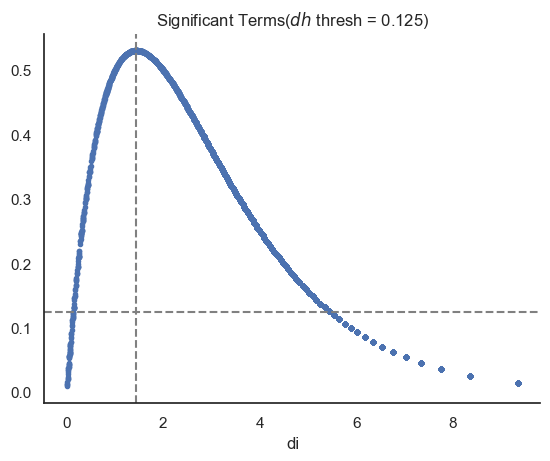

In [45]:
D = V.set_index('di').dh
ax = D.plot(style='.')
ax.axvline(D.idxmax(), ls='--', c='gray')
ax.axhline(sig_thresh, ls='--', c='gray')
sns.despine()
plt.title(f"Significant Terms($dh$ thresh = {sig_thresh})")
plt.show()


In [46]:
SIGS = V[V.dh >= sig_thresh]
(len(SIGS)/len(V))*100, len(SIGS)

(10.889546925012409, 6362)

In [47]:
SIGS.sample(5)

,df,dp,di,dh
term_str,,,,
safer,27,0.041538,4.589408,0.190637
jindo,23,0.035385,4.820734,0.170580
function,22,0.033846,4.884864,0.165334
situation,104,0.160000,2.643856,0.423017
intersection,26,0.040000,4.643856,0.185754


In [49]:
TFIDF_SIGS = TFIDF[SIGS.index].copy()
TFIDF_SIGS

,abandon,abandoned,abandoning,abilities,ability,able,aboard,above,abruptly,absence,...,yourselves,youth,youthful,youths,yup,zeal,zephyr,zipped,zipping,ﬂoor
title,,,,,,,,,,,,,,,,,,,,,
A Memory of Light,0.000115,0.000129,0.000065,0.000043,0.000148,0.000257,0.000000,0.000460,0.000000,0.000023,...,0.000107,0.000140,0.000051,0.000093,0.000000,0.000000,0.000000,0.000070,0.000000,0.000000
Arcanum Unbounded,0.000000,0.000269,0.000043,0.000000,0.000057,0.000247,0.000000,0.000055,0.000000,0.000000,...,0.000000,0.000328,0.000465,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Elantris,0.000021,0.000171,0.000049,0.000040,0.000185,0.000230,0.000000,0.000219,0.000011,0.000105,...,0.000035,0.000069,0.000026,0.000000,0.000000,0.000161,0.000000,0.000000,0.000015,0.000000
Isles of the Emberdark,0.000203,0.000000,0.000000,0.000542,0.000390,0.000300,0.000060,0.001600,0.000000,0.000160,...,0.000000,0.000418,0.000093,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Oathbringer,0.000086,0.000218,0.000000,0.000103,0.000086,0.000315,0.000032,0.000335,0.000000,0.000113,...,0.000082,0.000446,0.000021,0.000000,0.000000,0.000000,0.000000,0.000710,0.000256,0.000000
Rhythm of War,0.000180,0.000171,0.000000,0.000551,0.000391,0.000344,0.000000,0.000276,0.000000,0.000042,...,0.000052,0.000148,0.000000,0.000000,0.000000,0.000000,0.000000,0.000364,0.000164,0.000000
Shadows of Self,0.000000,0.000105,0.000000,0.000098,0.000151,0.000414,0.000000,0.000211,0.000000,0.000148,...,0.000000,0.000263,0.000000,0.000185,0.000069,0.000000,0.000000,0.000000,0.000000,0.000000
Steelheart,0.000298,0.000204,0.000144,0.000387,0.000144,0.000387,0.000000,0.000396,0.000040,0.000098,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000053,0.000000
The Aether of Night,0.000257,0.000140,0.000166,0.000045,0.000144,0.000386,0.000030,0.000104,0.000019,0.000045,...,0.000031,0.000051,0.000056,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [50]:
L0 = TFIDF_SIGS.astype('bool').astype('int')    # Binary (Pseudo L)
L1 = TFIDF_SIGS.apply(lambda x: x / x.sum(), 1) # Probabilistic
L2 = TFIDF_SIGS.apply(lambda x: x / norm(x), 1) # Pythagorean, AKA Euclidean

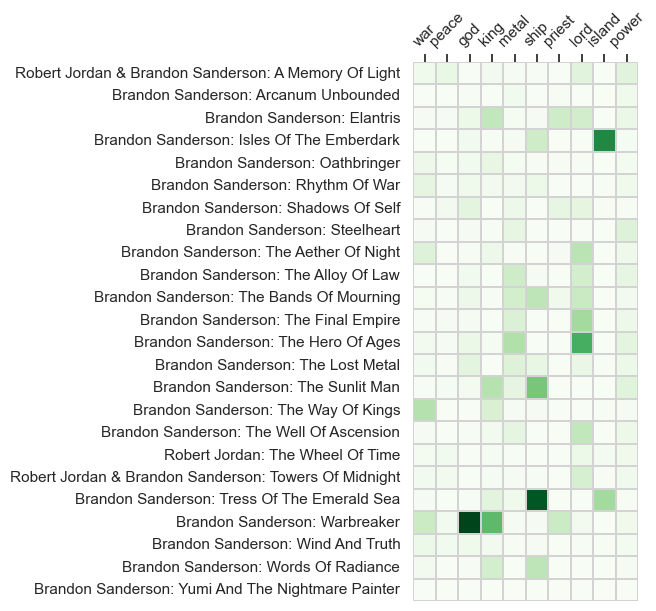

In [53]:
sample_terms = "war peace god king metal ship priest lord island power".split()
plt.figure(figsize=(10, 7))
ax = sns.heatmap(L1[sample_terms], 
            yticklabels = LIB.label.values,
            cmap="Greens", linewidth=.01, linecolor="lightgray", square=True, cbar=None)
ax.xaxis.tick_top()
ax.set(xlabel=None, ylabel=None)
plt.xticks(rotation=45)
plt.show()

In [55]:
PAIRS = pd.DataFrame(index=pd.MultiIndex.from_product([LIB.index.tolist(), LIB.index.tolist()])).reset_index()
PAIRS = PAIRS[PAIRS.level_0 < PAIRS.level_1].set_index(['level_0','level_1'])
PAIRS

Empty DataFrame
Columns: []
Index: [(A Memory of Light, Arcanum Unbounded), (A Memory of Light, Elantris), (A Memory of Light, Isles of the Emberdark), (A Memory of Light, Oathbringer), (A Memory of Light, Rhythm of War), (A Memory of Light, Shadows of Self), (A Memory of Light, Steelheart), (A Memory of Light, The Aether of Night), (A Memory of Light, The Alloy of Law), (A Memory of Light, The Bands of Mourning), (A Memory of Light, The Final Empire), (A Memory of Light, The Hero of Ages), (A Memory of Light, The Lost Metal), (A Memory of Light, The Sunlit Man), (A Memory of Light, The Way of Kings), (A Memory of Light, The Well of Ascension), (A Memory of Light, The Wheel of Time), (A Memory of Light, Towers of Midnight), (A Memory of Light, Tress of the Emerald Sea), (A Memory of Light, Warbreaker), (A Memory of Light, Wind and Truth), (A Memory of Light, Words of Radiance), (A Memory of Light, Yumi and the Nightmare Painter), (Arcanum Unbounded, Elantris), (Arcanum Unbounded, Isles of the Emberdark), (Arcanum Unbounded, Oathbringer), (Arcanum Unbounded, Rhythm of War), (Arcanum Unbounded, Shadows of Self), (Arcanum Unbounded, Steelheart), (Arcanum Unbounded, The Aether of Night), (Arcanum Unbounded, The Alloy of Law), (Arcanum Unbounded, The Bands of Mourning), (Arcanum Unbounded, The Final Empire), (Arcanum Unbounded, The Hero of Ages), (Arcanum Unbounded, The Lost Metal), (Arcanum Unbounded, The Sunlit Man), (Arcanum Unbounded, The Way of Kings), (Arcanum Unbounded, The Well of Ascension), (Arcanum Unbounded, The Wheel of Time), (Arcanum Unbounded, Towers of Midnight), (Arcanum Unbounded, Tress of the Emerald Sea), (Arcanum Unbounded, Warbreaker), (Arcanum Unbounded, Wind and Truth), (Arcanum Unbounded, Words of Radiance), (Arcanum Unbounded, Yumi and the Nightmare Painter), (Elantris, Isles of the Emberdark), (Elantris, Oathbringer), (Elantris, Rhythm of War), (Elantris, Shadows of Self), (Elantris, Steelheart), (Elantris, The Aether of Night), (Elantris, The Alloy of Law), (Elantris, The Bands of Mourning), (Elantris, The Final Empire), (Elantris, The Hero of Ages), (Elantris, The Lost Metal), (Elantris, The Sunlit Man), (Elantris, The Way of Kings), (Elantris, The Well of Ascension), (Elantris, The Wheel of Time), (Elantris, Towers of Midnight), (Elantris, Tress of the Emerald Sea), (Elantris, Warbreaker), (Elantris, Wind and Truth), (Elantris, Words of Radiance), (Elantris, Yumi and the Nightmare Painter), (Isles of the Emberdark, Oathbringer), (Isles of the Emberdark, Rhythm of War), (Isles of the Emberdark, Shadows of Self), (Isles of the Emberdark, Steelheart), (Isles of the Emberdark, The Aether of Night), (Isles of the Emberdark, The Alloy of Law), (Isles of the Emberdark, The Bands of Mourning), (Isles of the Emberdark, The Final Empire), (Isles of the Emberdark, The Hero of Ages), (Isles of the Emberdark, The Lost Metal), (Isles of the Emberdark, The Sunlit Man), (Isles of the Emberdark, The Way of Kings), (Isles of the Emberdark, The Well of Ascension), (Isles of the Emberdark, The Wheel of Time), (Isles of the Emberdark, Towers of Midnight), (Isles of the Emberdark, Tress of the Emerald Sea), (Isles of the Emberdark, Warbreaker), (Isles of the Emberdark, Wind and Truth), (Isles of the Emberdark, Words of Radiance), (Isles of the Emberdark, Yumi and the Nightmare Painter), (Oathbringer, Rhythm of War), (Oathbringer, Shadows of Self), (Oathbringer, Steelheart), (Oathbringer, The Aether of Night), (Oathbringer, The Alloy of Law), (Oathbringer, The Bands of Mourning), (Oathbringer, The Final Empire), (Oathbringer, The Hero of Ages), (Oathbringer, The Lost Metal), (Oathbringer, The Sunlit Man), (Oathbringer, The Way of Kings), (Oathbringer, The Well of Ascension), (Oathbringer, The Wheel of Time), (Oathbringer, Towers of Midnight), ...]

[276 rows x 0 columns]

In [56]:
PAIRS.index.names = ['doc_a', 'doc_b']
PAIRS.shape

(276, 0)

In [57]:
PAIRS.head()

Empty DataFrame
Columns: []
Index: [(A Memory of Light, Arcanum Unbounded), (A Memory of Light, Elantris), (A Memory of Light, Isles of the Emberdark), (A Memory of Light, Oathbringer), (A Memory of Light, Rhythm of War)]

In [58]:
pdist(TFIDF_SIGS, 'cosine')


array([0.92927123, 0.9316484 , 0.93684898, 0.88828419, 0.90041786,
       0.91921791, 0.812345  , 0.94407619, 0.91360185, 0.89990465,
       0.93726851, 0.90391074, 0.88596603, 0.91884494, 0.92604247,
       0.95428723, 0.33791172, 0.55976624, 0.93143205, 0.90946491,
       0.92056457, 0.90464464, 0.94239515, 0.95922119, 0.96873781,
       0.94131861, 0.94316722, 0.95325126, 0.89470094, 0.9628213 ,
       0.95091974, 0.94362023, 0.94369207, 0.94560683, 0.9214167 ,
       0.94791917, 0.93314954, 0.97345067, 0.94010537, 0.96206723,
       0.95414621, 0.93989143, 0.95485978, 0.95428346, 0.94412217,
       0.9693581 , 0.94818432, 0.95172929, 0.95521646, 0.90613772,
       0.96930767, 0.95445674, 0.94759146, 0.95835638, 0.94521015,
       0.93895407, 0.95867424, 0.96370891, 0.97213242, 0.93917424,
       0.95598889, 0.96105709, 0.93682661, 0.96272302, 0.95718774,
       0.96535474, 0.95142456, 0.95552206, 0.95863551, 0.90627191,
       0.97593937, 0.95710591, 0.94390167, 0.97037844, 0.96081

In [59]:
PAIRS['cityblock'] = pdist(TFIDF_SIGS, 'cityblock')
PAIRS['cityblock1'] = pdist(L1, 'cityblock')
PAIRS['cityblock2'] = pdist(L2, 'cityblock')
PAIRS['euclidean'] = pdist(TFIDF_SIGS, 'euclidean')
PAIRS['euclidean2'] = pdist(L2, 'euclidean') # Should be the same as cosine (colinear)
PAIRS['cosine'] = pdist(TFIDF_SIGS, 'cosine')
PAIRS['cosine2'] = pdist(L2, 'cosine')
PAIRS['jaccard'] = pdist(L0, 'jaccard')
PAIRS['dice'] = pdist(L0, 'dice')
PAIRS['js'] = pdist(L1, 'jensenshannon')

In [64]:
PAIRS.sample(20).sort_values('cityblock').style.background_gradient(colors)

In [65]:
PAIRS.to_csv(directory_path + "/BrandonSanderson_PAIRS.csv")

In [69]:
def hac(sim_method='cosine', linkage_method='complete', color_thresh=.3, figsize=(10, 10)):

    # Get the similarities among pairs
    sims = PAIRS[sim_method]
    
    # Generate the cluster tree
    tree = sch.linkage(sims, method=linkage_method)
    
    # Get labels for the leaves
    labels = LIB.label.values
    
    # Create a dendrogram from the tree
    sch.dendrogram(tree, 
        labels=labels, 
        orientation="left", 
        count_sort=True,
        distance_sort=True,
        above_threshold_color='.75',
        color_threshold=color_thresh
    )
    # Show threshhold
    ax = plt.gca()
    ax.axvline(color_thresh, c='gray', ls='--')

    # Change the appearance of ticks, tick labels, and gridlines
    plt.tick_params(axis='both', which='major', labelsize=10)    

    # Remove borders
    sns.despine(left=True, bottom=True)

    # Add title
    plt.title(f"{sim_method} + {linkage_method} ({color_thresh})", y=1.05)

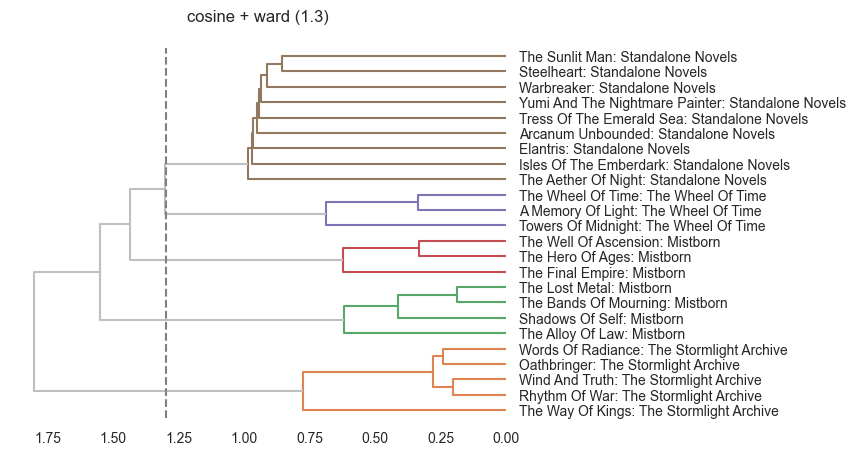

In [83]:
hac('cosine', 'ward',color_thresh=1.3)
plt.savefig(directory_path + "/Dendrogram.png", dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
plt.show()